In [1]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

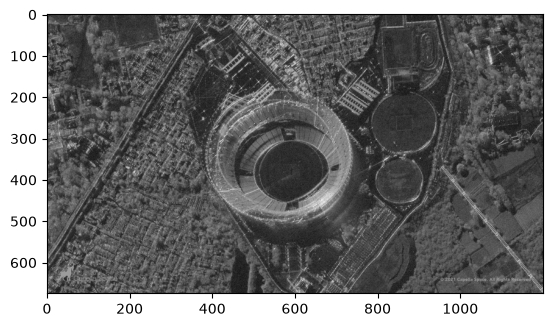

In [72]:
import numpy as np
import cv2
import copy
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")
plt.show()

<h1>1. Шум Гаусса</h1>

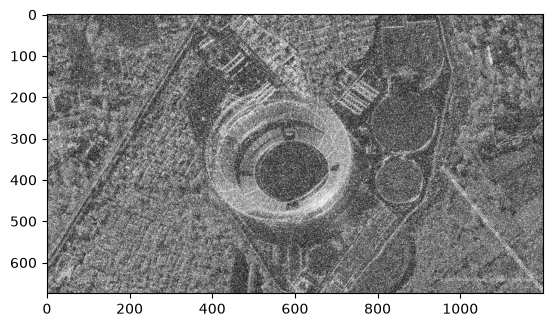

In [73]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray,noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")
plt.show()

<h1> 2. Постоянный шум </h1>

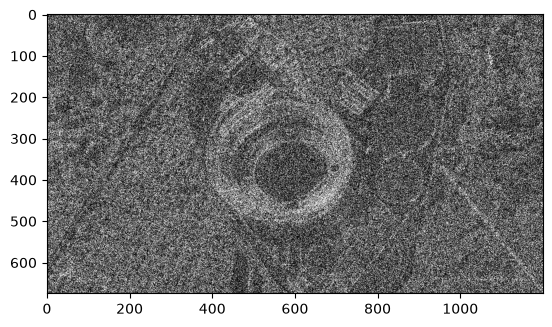

In [74]:
image_sp = copy.deepcopy(image_gray)
img_float = image_gray.astype(np.float32)
noise = np.random.uniform(-200, 200, img_float.shape)
noise_image = img_float + noise
noise_image = np.clip(noise_image, 0, 255).astype(np.uint8)
plt.imshow(noise_image, cmap='gray')
plt.show()

<h1>3. Медианный фильтр</h1>

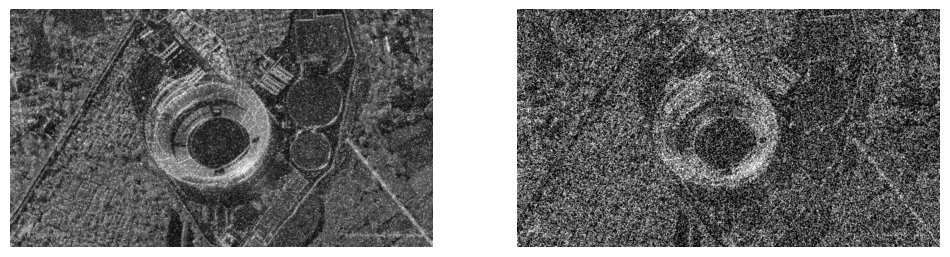

In [75]:
def calc_metrics(source, filtered):
    mse = mean_squared_error(source, filtered)
    (ssim, diff) = structural_similarity(source, filtered, full=True)
    return(mse, ssim)

metrics = {}
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
noise_image_median = cv2.medianBlur(noise_image,3)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_gauss_median, cmap='gray')
axes[0].axis('off')
axes[1].imshow(noise_image_median, cmap='gray')
axes[1].axis('off')
plt.show()
metrics["Медианный фильтр(Шум Гаусса)"] = calc_metrics(image_gray, image_gauss_median)
metrics["Медианный фильтр(Постоянный шум)"] = calc_metrics(image_gray, noise_image_median)

<h1>4. Фильтр Гаусса</h1>

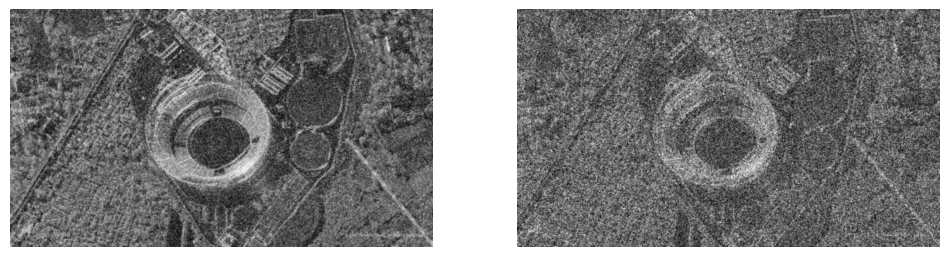

In [76]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5), 0)
noise_image_gauss = cv2.GaussianBlur(noise_image, (5,5), 0)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_gauss_gauss, cmap='gray')
axes[0].axis('off')
axes[1].imshow(noise_image_gauss, cmap='gray')
axes[1].axis('off')
plt.show()
metrics["Фильтр Гаусса(Шум Гаусса)"] = calc_metrics(image_gray, image_gauss_gauss)
metrics["Фильтр Гаусса(Постоянный шум)"] = calc_metrics(image_gray, noise_image_gauss)

<h1>5. Билатериальный фильтр</h1>

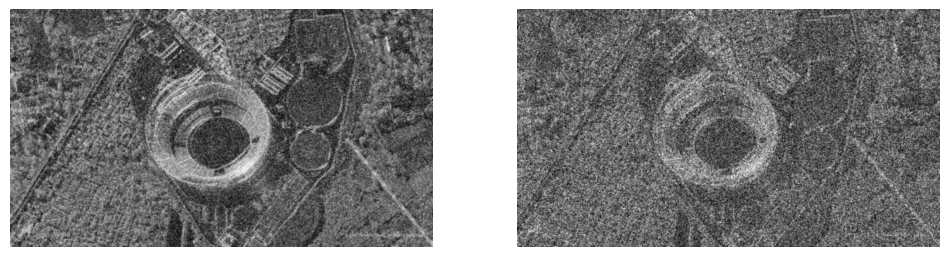

In [77]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)
noise_image_bilat = cv2.bilateralFilter(noise_image,9,75,75)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_gauss_gauss, cmap='gray')
axes[0].axis('off')
axes[1].imshow(noise_image_gauss, cmap='gray')
axes[1].axis('off')
plt.show()
metrics["Билатериальный фильтр(Шум Гаусса)"] = calc_metrics(image_gray, image_gauss_bilat)
metrics["Билатериальный фильтр(Постоянный шум)"] = calc_metrics(image_gray, noise_image_bilat)

<h1>6. Фильтр нелокальных средних</h1>

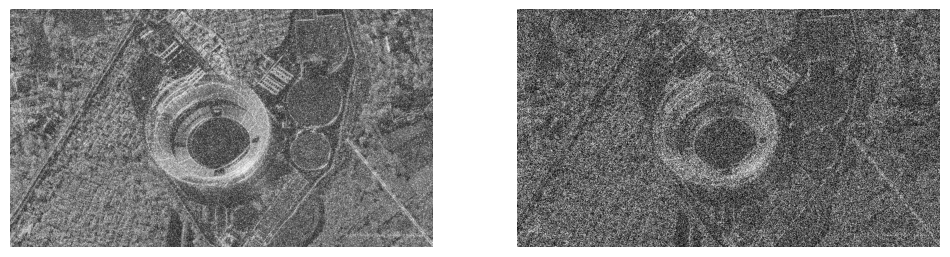

In [78]:
image_gauss_nlm10 = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)
noise_image_nlm10 = cv2.fastNlMeansDenoising(noise_image, h=10)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_gauss_nlm10, cmap='gray')
axes[0].axis('off')
axes[1].imshow(noise_image_nlm10, cmap='gray')
axes[1].axis('off')
plt.show()
metrics["Фильтр нелокальных средних[h = 10](Шум Гаусса)"] = calc_metrics(image_gray, image_gauss_nlm10)
metrics["Фильтр нелокальных средних[h = 10](Постоянный шум)"] = calc_metrics(image_gray, noise_image_nlm10)

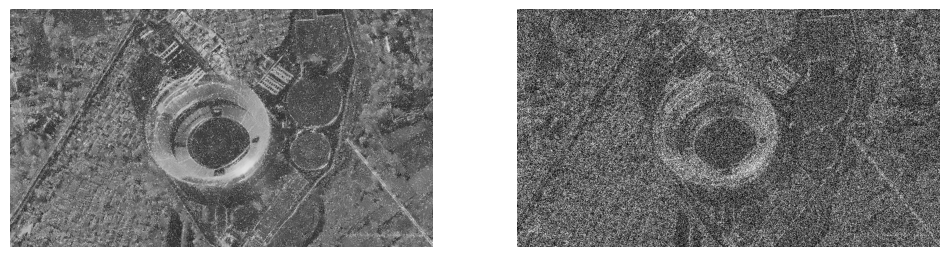

In [79]:
image_gauss_nlm30 = cv2.fastNlMeansDenoising(image_noise_gauss, h=30)
noise_image_nlm30 = cv2.fastNlMeansDenoising(noise_image, h=30)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_gauss_nlm30, cmap='gray')
axes[0].axis('off')
axes[1].imshow(noise_image_nlm30, cmap='gray')
axes[1].axis('off')
plt.show()
metrics["Фильтр нелокальных средних[h = 30](Шум Гаусса)"] = calc_metrics(image_gray, image_gauss_nlm30)
metrics["Фильтр нелокальных средних[h = 30](Постоянный шум)"] = calc_metrics(image_gray, noise_image_nlm30)

<h1>7. Сравнение характеристик</h1>

In [80]:
print(f"{'Фильтр / Шум':<55} | {'MSE':<12} | {'SSIM':<8}")
print("-" * 83)

for name, (mse, ssim) in metrics.items():
    mse_val = f"{mse:.2f}"
    mse_str = f"\033[1m{mse_val:>12}\033[0m"

    ssim_val = f"{ssim:.4f}"
    ssim_str = f"\033[1m{ssim_val:>8}\033[0m"
    
    print(f"{name:<55} | {mse_str} | {ssim_str}")

print("-" * 83)


print("Шум Гаусса:")

print(f"   Лучший по MSE  (минимальная ошибка):  \033[1m{gauss_best_mse}\033[0m (MSE: {metrics[gauss_best_mse][0]:.2f})")
print(f"   Лучший по SSIM (максимальное сходство): \033[1m{gauss_best_ssim}\033[0m (SSIM: {metrics[gauss_best_ssim][1]:.4f})")

print("-" * 60)


print("Постоянный шум:")

print(f"   Лучший по MSE  (минимальная ошибка):  \033[1m{const_best_mse}\033[0m (MSE: {metrics[const_best_mse][0]:.2f})")
print(f"   Лучший по SSIM (максимальное сходство): \033[1m{const_best_ssim}\033[0m (SSIM: {metrics[const_best_ssim][1]:.4f})")


Фильтр / Шум                                            | MSE          | SSIM    
-----------------------------------------------------------------------------------
Медианный фильтр(Шум Гаусса)                            |      1030.70 |   0.4318
Медианный фильтр(Постоянный шум)                        |      3115.39 |   0.1250
Фильтр Гаусса(Шум Гаусса)                               |      1759.21 |   0.4888
Фильтр Гаусса(Постоянный шум)                           |      1161.88 |   0.2736
Билатериальный фильтр(Шум Гаусса)                       |      1835.08 |   0.3154
Билатериальный фильтр(Постоянный шум)                   |      4863.86 |   0.0803
Фильтр нелокальных средних[h = 10](Шум Гаусса)          |      4223.77 |   0.1877
Фильтр нелокальных средних[h = 10](Постоянный шум)      |      8412.71 |   0.0570
Фильтр нелокальных средних[h = 30](Шум Гаусса)          |      2933.52 |   0.2550
Фильтр нелокальных средних[h = 30](Постоянный шум)      |      8412.56 |   0.0570
--------------